In [1]:
import subprocess, os, shutil

REPO_URL = "https://github.com/safety-research/legibility.git"
REPO_DIR = "/workspace/18-4-2026"
EXP_DIR = os.path.join(REPO_DIR, "experiments", "2026", "15-4-2026")

# Clone or pull latest (fetch + reset to ensure we have the newest commit)
if not os.path.exists(os.path.join(REPO_DIR, ".git")):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin"], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "origin/main"], check=True)

# Install git-lfs if not available, then pull LFS files
if shutil.which("git-lfs") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=False)
    subprocess.run(["apt-get", "install", "-y", "-qq", "git-lfs"], check=False)
    subprocess.run(["git", "lfs", "install"], check=False)
subprocess.run(["git", "-C", REPO_DIR, "lfs", "pull"], check=False)

# Install dependencies
req_path = os.path.join(EXP_DIR, "requirements.txt")
if os.path.exists(req_path):
    subprocess.run(["pip", "install", "-q", "-r", req_path], check=True)
else:
    print(f"WARNING: {req_path} not found, skipping pip install")

# Set working directory so Path.cwd().parent resolves to experiment root
os.chdir(os.path.join(EXP_DIR, "notebooks"))

HEAD is now at cbbc499 Add Phase 1 results files needed by Phase 2 notebooks


# NB3: Linear Probes for Legibility (Experiments A1 + B)

**CPU notebook** (~15 min). Trains linear probes on pre-extracted activations.

**Experiment A1** -- Per-layer probes:
- (a) Answer probe: predict correct answer letter from last-token activations
- (b) Legibility probe: predict REASONING_LEGIBLE vs ILLEGIBLE
- Compare AUROC across layers, include foreignness covariate

**Experiment B** -- Pre-CoT illegibility predictor:
- Binary probe on question-token activations (before `<think>`)
- 5-fold stratified CV with bootstrap CIs
- Key result: if AUROC > 0.65, illegibility is predictable before generation

**Requires:** NB1 outputs (`activations/{G1,G3}_last_token/`, `activations/{G1,G3}_question_token/`)

In [2]:
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

sys.path.insert(0, str(Path.cwd().parent))
from phase2_utils import (
    load_phase1_results, get_labeled_cots, join_cots_with_labels,
    load_foreignness_scores, load_activations, train_binary_probe,
    permutation_test, plot_layer_probe_curve, plot_comparison_curves,
    bootstrap_ci_metric, print_phase1_summary,
    ACTIVATIONS_DIR, PHASE2_RESULTS_DIR,
)

PHASE2_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print_phase1_summary()

Total records: 564
Classified: 287, Filtered: 277
R4 transform: _t64
Label counts:
  ANSWER_LEAKED: 148
  FILTERED: 277
  ILLEGIBLE: 60
  REASONING_LEGIBLE: 79

Per-generator:
  G1: 92 classified (leaked=42%, legible=32%, illegible=26%)
  G2: 94 classified (leaked=63%, legible=23%, illegible=14%)
  G3: 101 classified (leaked=50%, legible=28%, illegible=23%)
  G1 within-Q pairs: 0
  G3 within-Q pairs: 0


In [3]:
# Checkpoint: check if final output already exists
_output_path = PHASE2_RESULTS_DIR / 'probe_results.json'
if _output_path.exists():
    import json as _json
    with open(_output_path) as _f:
        _saved = _json.load(_f)
    print(f"CACHED: {_output_path} exists with {len(_saved)} experiment groups.")
    for key in _saved:
        print(f"  {key}: {list(_saved[key].keys()) if isinstance(_saved[key], dict) else 'present'}")
    print("Delete this file and re-run to recompute.")

In [4]:
# Load pre-extracted activations and their metadata
g3_last = load_activations(ACTIVATIONS_DIR / "G3_last_token")
g1_last = load_activations(ACTIVATIONS_DIR / "G1_last_token")
g3_question = load_activations(ACTIVATIONS_DIR / "G3_question_token")
g1_question = load_activations(ACTIVATIONS_DIR / "G1_question_token")

# Load metadata to get sample ordering and labels
with open(ACTIVATIONS_DIR / "G3_last_token" / "metadata.json") as f:
    g3_meta = json.load(f)
with open(ACTIVATIONS_DIR / "G1_last_token" / "metadata.json") as f:
    g1_meta = json.load(f)

# Extract labels from metadata (sample_ids contains tuples of (sid, gid, epoch, label))
g3_labels = [s[3] for s in g3_meta['sample_ids']]
g1_labels = [s[3] for s in g1_meta['sample_ids']]

print(f"G3 activations: {len(g3_labels)} samples, layers={sorted(g3_last.keys())}")
print(f"G1 activations: {len(g1_labels)} samples, layers={sorted(g1_last.keys())}")
print(f"G3 label dist: {dict(Counter(g3_labels))}")
print(f"G1 label dist: {dict(Counter(g1_labels))}")

G3 activations: 101 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 63]
G1 activations: 92 samples, layers=[0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60, 63]
G3 label dist: {'REASONING_LEGIBLE': 28, 'ANSWER_LEAKED': 50, 'ILLEGIBLE': 23}
G1 label dist: {'REASONING_LEGIBLE': 29, 'ANSWER_LEAKED': 39, 'ILLEGIBLE': 24}


## Experiment A1(b): Legibility Probe

Binary classification: REASONING_LEGIBLE (1) vs ILLEGIBLE (0) from last-token activations.

In [5]:
# Build binary labels for legibility: REASONING_LEGIBLE=1, ILLEGIBLE=0
# Exclude ANSWER_LEAKED samples
def build_legibility_labels(label_list):
    """Return (mask, binary_labels) for legible vs illegible."""
    mask = []
    labels = []
    for l in label_list:
        if l == 'REASONING_LEGIBLE':
            mask.append(True)
            labels.append(1)
        elif l == 'ILLEGIBLE':
            mask.append(True)
            labels.append(0)
        else:
            mask.append(False)
            labels.append(-1)
    return np.array(mask), np.array(labels)

g3_mask, g3_binary = build_legibility_labels(g3_labels)
g1_mask, g1_binary = build_legibility_labels(g1_labels)

print(f"G3: {g3_mask.sum()} legible/illegible samples ({(g3_binary[g3_mask]==1).sum()} legible, {(g3_binary[g3_mask]==0).sum()} illegible)")
print(f"G1: {g1_mask.sum()} legible/illegible samples ({(g1_binary[g1_mask]==1).sum()} legible, {(g1_binary[g1_mask]==0).sum()} illegible)")

G3: 51 legible/illegible samples (28 legible, 23 illegible)
G1: 53 legible/illegible samples (29 legible, 24 illegible)


In [6]:
# Train per-layer legibility probes for G3
g3_legibility_results = {}

for layer_idx in sorted(g3_last.keys()):
    features = g3_last[layer_idx][g3_mask]
    labels = g3_binary[g3_mask]
    
    result = train_binary_probe(features, labels, n_splits=5)
    g3_legibility_results[layer_idx] = result
    print(f"  G3 Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} "
          f"CI=[{result['auroc_ci'][0]:.3f}, {result['auroc_ci'][1]:.3f}] "
          f"n={result['n_samples']}")

  G3 Layer   0: AUROC=0.579 CI=[0.434, 0.704] n=51
  G3 Layer   4: AUROC=0.645 CI=[0.573, 0.725] n=51
  G3 Layer   8: AUROC=0.517 CI=[0.394, 0.639] n=51
  G3 Layer  12: AUROC=0.521 CI=[0.384, 0.666] n=51
  G3 Layer  16: AUROC=0.540 CI=[0.383, 0.703] n=51
  G3 Layer  20: AUROC=0.560 CI=[0.428, 0.698] n=51
  G3 Layer  24: AUROC=0.589 CI=[0.457, 0.738] n=51
  G3 Layer  28: AUROC=0.569 CI=[0.415, 0.724] n=51
  G3 Layer  32: AUROC=0.607 CI=[0.466, 0.740] n=51
  G3 Layer  36: AUROC=0.674 CI=[0.550, 0.798] n=51
  G3 Layer  40: AUROC=0.579 CI=[0.471, 0.689] n=51
  G3 Layer  44: AUROC=0.552 CI=[0.462, 0.627] n=51
  G3 Layer  48: AUROC=0.507 CI=[0.324, 0.654] n=51
  G3 Layer  52: AUROC=0.540 CI=[0.449, 0.619] n=51
  G3 Layer  56: AUROC=0.489 CI=[0.384, 0.595] n=51
  G3 Layer  60: AUROC=0.528 CI=[0.410, 0.654] n=51
  G3 Layer  63: AUROC=0.578 CI=[0.430, 0.725] n=51


In [7]:
# Train per-layer legibility probes for G1
g1_legibility_results = {}

for layer_idx in sorted(g1_last.keys()):
    features = g1_last[layer_idx][g1_mask]
    labels = g1_binary[g1_mask]
    
    result = train_binary_probe(features, labels, n_splits=5)
    g1_legibility_results[layer_idx] = result
    print(f"  G1 Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} "
          f"CI=[{result['auroc_ci'][0]:.3f}, {result['auroc_ci'][1]:.3f}]")

  G1 Layer   0: AUROC=0.624 CI=[0.484, 0.761]
  G1 Layer   4: AUROC=0.609 CI=[0.436, 0.778]
  G1 Layer   8: AUROC=0.555 CI=[0.371, 0.733]
  G1 Layer  12: AUROC=0.557 CI=[0.433, 0.697]
  G1 Layer  16: AUROC=0.579 CI=[0.492, 0.690]
  G1 Layer  20: AUROC=0.566 CI=[0.495, 0.671]
  G1 Layer  24: AUROC=0.499 CI=[0.439, 0.560]
  G1 Layer  28: AUROC=0.562 CI=[0.473, 0.667]
  G1 Layer  32: AUROC=0.533 CI=[0.435, 0.640]
  G1 Layer  36: AUROC=0.534 CI=[0.430, 0.643]
  G1 Layer  40: AUROC=0.573 CI=[0.453, 0.653]
  G1 Layer  44: AUROC=0.543 CI=[0.435, 0.647]
  G1 Layer  48: AUROC=0.521 CI=[0.341, 0.697]
  G1 Layer  52: AUROC=0.555 CI=[0.371, 0.742]
  G1 Layer  56: AUROC=0.552 CI=[0.373, 0.724]
  G1 Layer  60: AUROC=0.573 CI=[0.420, 0.713]
  G1 Layer  63: AUROC=0.461 CI=[0.337, 0.598]


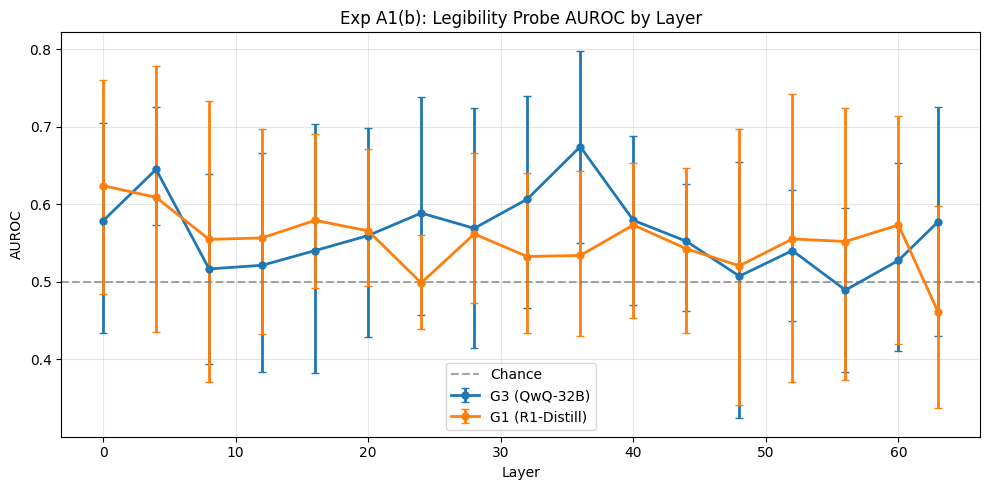

In [8]:
# Plot comparison: G1 vs G3 legibility probes
fig, ax = plot_comparison_curves(
    {"G3 (QwQ-32B)": g3_legibility_results, "G1 (R1-Distill)": g1_legibility_results},
    title="Exp A1(b): Legibility Probe AUROC by Layer",
    save_path=str(PHASE2_RESULTS_DIR / "a1b_legibility_probe.png"),
)
plt.show()

In [9]:
# Permutation test on best layer for each model
for name, results_dict, last_acts, mask, binary in [
    ("G3", g3_legibility_results, g3_last, g3_mask, g3_binary),
    ("G1", g1_legibility_results, g1_last, g1_mask, g1_binary),
]:
    best_layer = max(results_dict, key=lambda k: results_dict[k]['auroc'])
    features = last_acts[best_layer][mask]
    labels = binary[mask]
    
    perm = permutation_test(features, labels, n_permutations=100)
    print(f"{name} best layer={best_layer}: observed={perm['observed_auroc']:.3f}, "
          f"null={perm['null_mean']:.3f}+/-{perm['null_std']:.3f}, p={perm['p_value']:.4f}")

G3 best layer=36: observed=0.674, null=0.497+/-0.124, p=0.0700
G1 best layer=0: observed=0.624, null=0.497+/-0.099, p=0.0700


## Experiment A1(a): Answer Probe

Predict the correct answer from last-token activations. Hypothesis: answer probes
may succeed on both legible and illegible CoTs (the model computed the answer
regardless of whether it's legible to readers).

In [10]:
# For answer probes, we need to encode the target answer.
# For MCQA: target is a letter (A-E) -> encode as integer.
# For open-ended math: skip (too many unique answers for a simple probe).

results = load_phase1_results()
cots_g3 = join_cots_with_labels(generator_ids=["G3"])
cots_g3 = sorted(cots_g3, key=lambda x: (x['sample_id'], x['epoch']))

# Build answer labels for MCQA samples only
g3_answer_mask = []
g3_answer_labels = []
for c in cots_g3:
    is_mcqa = c.get('cot_metadata', {}).get('task_type') == 'multiple_choice'
    if is_mcqa and c['target'] in 'ABCDE':
        g3_answer_mask.append(True)
        g3_answer_labels.append(ord(c['target']) - ord('A'))
    else:
        g3_answer_mask.append(False)
        g3_answer_labels.append(-1)

g3_answer_mask = np.array(g3_answer_mask)
g3_answer_labels = np.array(g3_answer_labels)
print(f"MCQA samples for answer probe: {g3_answer_mask.sum()}")
print(f"Answer distribution: {dict(Counter(g3_answer_labels[g3_answer_mask]))}")

MCQA samples for answer probe: 59
Answer distribution: {np.int64(1): 18, np.int64(3): 15, np.int64(2): 16, np.int64(0): 10}


In [ ]:
# Train answer probes (multi-class) at each layer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

g3_answer_results = {}
for layer_idx in sorted(g3_last.keys()):
    features = g3_last[layer_idx][g3_answer_mask]
    labels = g3_answer_labels[g3_answer_mask]
    
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    probe = LogisticRegression(max_iter=1000, random_state=42)
    
    # Use accuracy for multi-class (not AUROC)
    cv_scores = cross_val_score(probe, features_scaled, labels, cv=cv, scoring='accuracy')
    
    g3_answer_results[layer_idx] = {
        'accuracy': float(np.mean(cv_scores)),
        'accuracy_std': float(np.std(cv_scores)),
        'auroc': float(np.mean(cv_scores)),  # for plotting compatibility
        'auroc_ci': (float(np.mean(cv_scores) - 1.96*np.std(cv_scores)),
                     float(np.mean(cv_scores) + 1.96*np.std(cv_scores))),
    }
    print(f"  G3 Layer {layer_idx:3d}: Acc={np.mean(cv_scores):.3f} +/- {np.std(cv_scores):.3f}")

# Chance level for 4-choice MCQA
print(f"\nChance level: {1.0/len(set(g3_answer_labels[g3_answer_mask])):.3f}")

In [ ]:
# Split answer probe by legibility class
# Does the answer probe work equally well on legible vs illegible CoTs?
g3_leg_labels_all = [s[3] for s in g3_meta['sample_ids']]

for legibility_class in ['REASONING_LEGIBLE', 'ILLEGIBLE']:
    class_mask = np.array([
        g3_answer_mask[i] and g3_leg_labels_all[i] == legibility_class
        for i in range(len(g3_leg_labels_all))
    ])
    if class_mask.sum() < 10:
        print(f"  {legibility_class}: only {class_mask.sum()} MCQA samples, skipping")
        continue
    
    # Use best layer from overall answer probe
    best_layer = max(g3_answer_results, key=lambda k: g3_answer_results[k]['accuracy'])
    features = g3_last[best_layer][class_mask]
    labels = g3_answer_labels[class_mask]
    
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)
    probe = LogisticRegression(max_iter=1000, random_state=42)
    
    if len(set(labels)) > 1:
        cv = StratifiedKFold(n_splits=min(5, class_mask.sum() // 3), shuffle=True, random_state=42)
        cv_scores = cross_val_score(probe, features_scaled, labels, cv=cv, scoring='accuracy')
        print(f"  {legibility_class} (layer {best_layer}): Acc={np.mean(cv_scores):.3f} n={class_mask.sum()}")
    else:
        print(f"  {legibility_class}: only 1 class in answers, skipping")

## Experiment B: Pre-CoT Illegibility Prediction

Can we predict whether a CoT will be legible or illegible from the question-token
activations (before `<think>`)? If AUROC > 0.65, illegibility is predictable
before generation and could be used as a generation-time monitor.

In [ ]:
# Train pre-CoT legibility probes
print("=== Experiment B: Pre-CoT Illegibility Prediction ===")

for name, q_acts, mask, binary in [
    ("G3", g3_question, g3_mask, g3_binary),
    ("G1", g1_question, g1_mask, g1_binary),
]:
    print(f"\n--- {name} ---")
    best_auroc = 0
    best_layer = None
    
    for layer_idx in sorted(q_acts.keys()):
        features = q_acts[layer_idx][mask]
        labels = binary[mask]
        
        if len(features) < 10:
            print(f"  Layer {layer_idx}: insufficient samples ({len(features)})")
            continue
        
        result = train_binary_probe(features, labels, n_splits=5)
        print(f"  Layer {layer_idx:3d}: AUROC={result['auroc']:.3f} CI={result['auroc_ci']}")
        
        if result['auroc'] > best_auroc:
            best_auroc = result['auroc']
            best_layer = layer_idx
    
    print(f"\n  Best: layer {best_layer}, AUROC={best_auroc:.3f}")
    
    # Permutation test on best layer
    features = q_acts[best_layer][mask]
    labels = binary[mask]
    perm = permutation_test(features, labels, n_permutations=100)
    print(f"  Permutation test: observed={perm['observed_auroc']:.3f}, "
          f"null={perm['null_mean']:.3f}, p={perm['p_value']:.4f}")
    
    # Key finding
    if best_auroc > 0.65:
        print(f"  >> RESULT: Illegibility IS predictable before generation (AUROC={best_auroc:.3f} > 0.65)")
    else:
        print(f"  >> RESULT: Illegibility NOT clearly predictable before generation (AUROC={best_auroc:.3f})")

## Foreignness Covariate Analysis

Report probe AUROC with and without foreignness to isolate distributional shift from content.

In [ ]:
# Load foreignness scores and add as a covariate
foreignness = load_foreignness_scores()
print(f"Loaded {len(foreignness)} foreignness scores")

# For each G3 sample, get mean foreignness across readers
cots_g3_sorted = sorted(join_cots_with_labels(generator_ids=['G3']),
                        key=lambda x: (x['sample_id'], x['epoch']))

g3_foreignness = []
for c in cots_g3_sorted:
    scores = []
    for rid in ['R1', 'R2', 'R3']:
        key = (c['sample_id'], c['generator_id'], c['epoch'], rid)
        if key in foreignness:
            scores.append(foreignness[key])
    g3_foreignness.append(np.mean(scores) if scores else np.nan)
g3_foreignness = np.array(g3_foreignness)

print(f"Foreignness available for {np.isfinite(g3_foreignness).sum()}/{len(g3_foreignness)} samples")
print(f"Mean foreignness: legible={g3_foreignness[g3_mask & (g3_binary==1)].mean():.2f}, "
      f"illegible={g3_foreignness[g3_mask & (g3_binary==0)].mean():.2f}")

In [ ]:
# Compare: probe with vs without foreignness covariate
best_layer_g3 = max(g3_legibility_results, key=lambda k: g3_legibility_results[k]['auroc'])
features_base = g3_last[best_layer_g3][g3_mask]
labels = g3_binary[g3_mask]
foreignness_subset = g3_foreignness[g3_mask]

# Valid foreignness mask
valid_f = np.isfinite(foreignness_subset)

if valid_f.sum() > 20:
    # Without foreignness
    result_no_f = train_binary_probe(features_base[valid_f], labels[valid_f])
    print(f"Without foreignness: AUROC={result_no_f['auroc']:.3f} CI={result_no_f['auroc_ci']}")
    
    # With foreignness as additional feature
    features_with_f = np.column_stack([features_base[valid_f], foreignness_subset[valid_f].reshape(-1, 1)])
    result_with_f = train_binary_probe(features_with_f, labels[valid_f])
    print(f"With foreignness:    AUROC={result_with_f['auroc']:.3f} CI={result_with_f['auroc_ci']}")
    
    # Foreignness-only probe
    result_f_only = train_binary_probe(foreignness_subset[valid_f].reshape(-1, 1), labels[valid_f])
    print(f"Foreignness only:    AUROC={result_f_only['auroc']:.3f} CI={result_f_only['auroc_ci']}")
else:
    print(f"Only {valid_f.sum()} samples with foreignness scores, skipping covariate analysis")

In [ ]:
# Save all probe results
def serialize_probe_results(results_dict):
    """Remove non-serializable objects (sklearn models) for JSON."""
    clean = {}
    for layer_idx, r in results_dict.items():
        clean[int(layer_idx)] = {
            k: v for k, v in r.items()
            if k not in ('probe_model', 'scaler')
        }
    return clean

output = {
    'exp_a1b_legibility': {
        'G3': serialize_probe_results(g3_legibility_results),
        'G1': serialize_probe_results(g1_legibility_results),
    },
    'exp_a1a_answer': {
        'G3': serialize_probe_results(g3_answer_results),
    },
}

with open(PHASE2_RESULTS_DIR / 'probe_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)
print(f"Results saved to {PHASE2_RESULTS_DIR / 'probe_results.json'}")